/home/ulrikts/Documents/NTNU/TIO4900-Replication/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/ulrikts/Documents/NTNU/TIO4900-Replication/utils/macro_grouping.py:219: UserWarning: The following series are defined in get_fredmd_grouping() but are not present in the FRED-MD data: ['ACOGNO', 'TWEXAFEGSMTHx']. They may have been dropped or renamed.
  warnings.warn(
/home/ulrikts/Documents/NTNU/TIO4900-Replication/utils/macro_grouping.py:168: UserWarning: 2 entries in series_to_group are not present in the DataFrame columns: ['ACOGNO', 'TWEXAFEGSMTHx']
  warnings.warn(


Run directory: /home/ulrikts/Documents/NTNU/TIO4900-Replication/artifacts/orchestrator_runs/run_1971_2018_lw_ANNUAL/macro_fwd_ann_fwd3_macro32&16&8_100runs_top10/20260414_192503
Run name: macro_fwd_ann_fwd3_macro32&16&8_100runs_top10
Reported maturities from run_config: ['24', '36', '48', '60', '84', '120']
topk output order: ['24', '36', '48', '60', '72', '84', '96', '108', '120']
Top-k tensor shape: (557, 9, 10)


Rolling SHAP maturity 120: 100%|██████████| 336/336 [00:56<00:00,  5.99it/s]


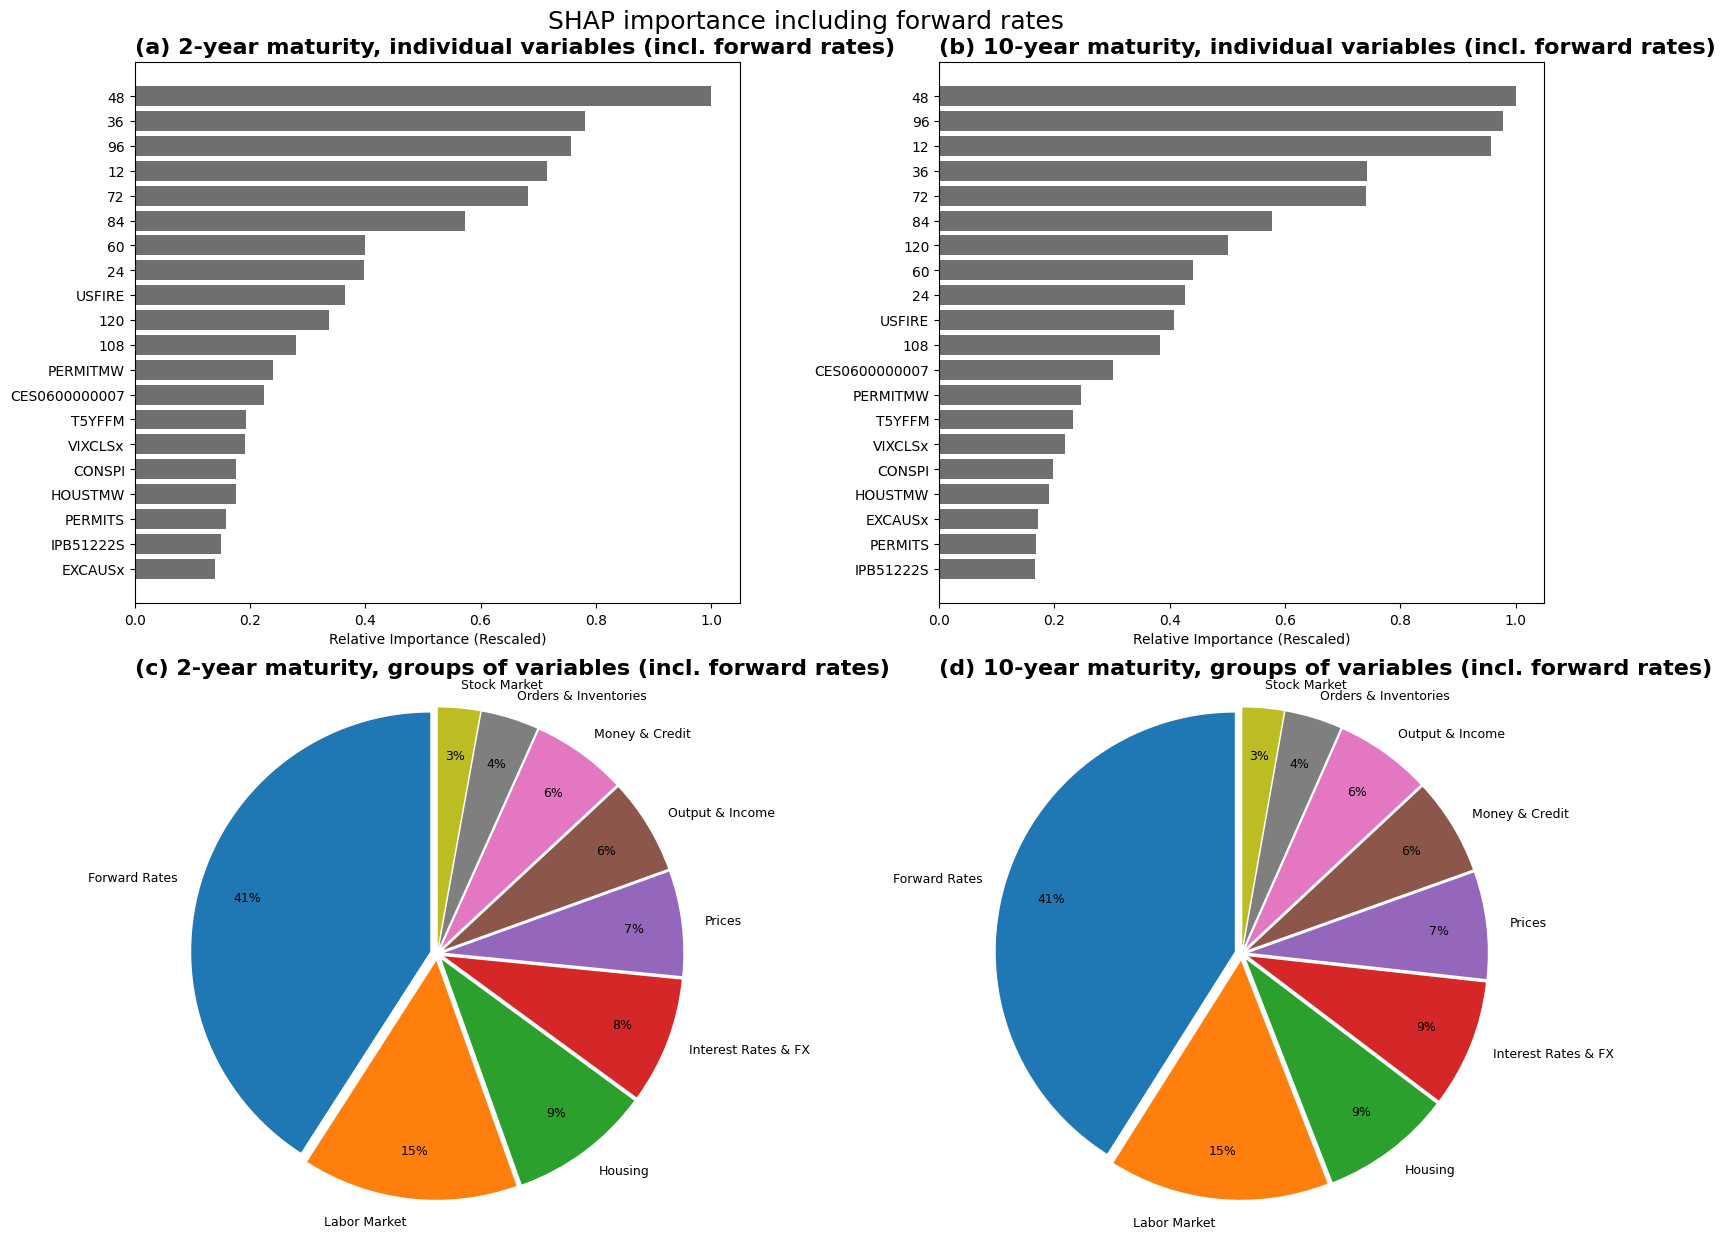

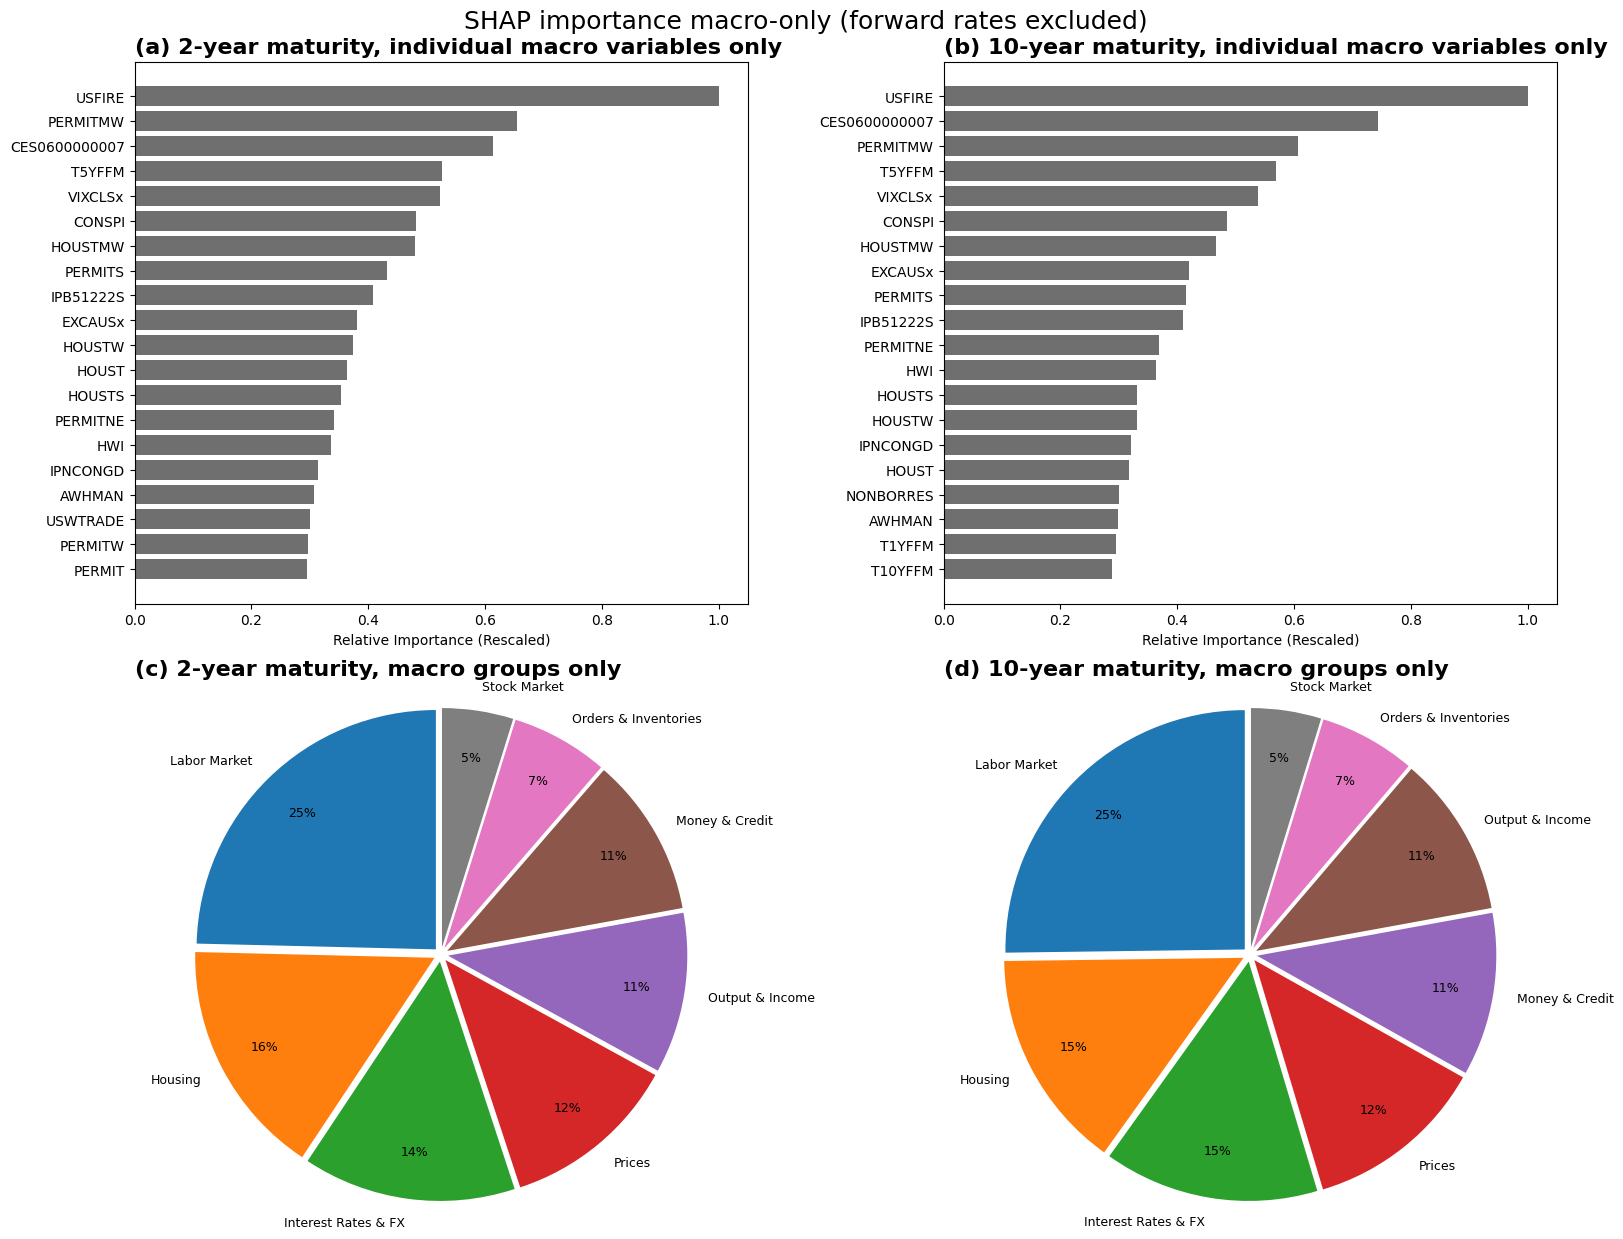

Time steps used (2-year): 336
Time steps used (10-year): 336


,group_plot,mean_abs_shap,share
0,Forward Rates,0.951436,0.409053
3,Labor Market,0.338348,0.145467
1,Housing,0.220683,0.094879
2,Interest Rates & FX,0.197697,0.084997
7,Prices,0.164443,0.070699
6,Output & Income,0.149185,0.064140
4,Money & Credit,0.147958,0.063612
5,Orders & Inventories,0.090076,0.038727
8,Stock Market,0.066120,0.028427


In [8]:
import sys
import os
from pathlib import Path

sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import shap
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from utils.macro_grouping import add_group_level, build_full_group_mapping
from models.macro_forward_ann import _TwoTowerMLPNetwork


# -------------------------
# Local data utilities (copied from base_utils portions, without statsmodels dependency)
# -------------------------
REPO_ROOT = Path('..').resolve()


def load_fred_md_data(filepath: str) -> tuple[pd.DataFrame, pd.Series]:
    full_data = pd.read_csv(filepath)

    transform_codes = full_data.iloc[0, 1:].astype(int)
    transform_codes.name = 'transform_codes'

    data = full_data.iloc[1:].copy().reset_index(drop=True)
    data['date'] = pd.to_datetime(data['date'], format='%m/%d/%Y')
    data = data.set_index('date')

    data.index = pd.to_datetime(data.index)
    data.index = pd.DatetimeIndex([(dt.replace(day=1) - pd.Timedelta(days=1)).normalize() for dt in data.index])
    data.index.name = 'date'

    for col in data.columns:
        data[col] = pd.to_numeric(data[col], errors='coerce')

    return data, transform_codes


def apply_fred_transformations(data: pd.DataFrame, transform_codes: pd.Series) -> pd.DataFrame:
    transformed = data.copy()

    for col in data.columns:
        if col not in transform_codes.index:
            continue

        code = transform_codes[col]
        series = data[col].copy()

        if series.isna().all():
            continue

        if code == 1:
            transformed[col] = series
        elif code == 2:
            transformed[col] = series.diff()
        elif code == 3:
            transformed[col] = series.diff().diff()
        elif code == 4:
            transformed[col] = np.log(series.where(series > 0))
        elif code == 5:
            transformed[col] = np.log(series.where(series > 0)).diff()
        elif code == 6:
            transformed[col] = np.log(series.where(series > 0)).diff().diff()
        elif code == 7:
            transformed[col] = (series / series.shift(1) - 1).diff()
        else:
            transformed[col] = series

    return transformed


def get_fred_data(filepath: str, start: str, end: str) -> pd.DataFrame:
    path = Path(filepath)
    if not path.is_absolute():
        path = REPO_ROOT / path

    fred_raw, transform_codes = load_fred_md_data(str(path))
    if 'UMCSENTx' in fred_raw.columns:
        fred_raw['UMCSENTx'] = fred_raw['UMCSENTx'].ffill()

    fred_md = apply_fred_transformations(fred_raw, transform_codes)
    return fred_md[start:end]


def get_yields(type: str, start: str, end: str, maturities: list[str]) -> pd.DataFrame:
    if type != 'lw':
        raise ValueError('This analysis cell currently expects type=lw to mirror the run config')

    yields = pd.read_csv(REPO_ROOT / 'data' / 'lw_yields.csv', index_col=0, comment='%')
    yields.index.name = 'date'
    yields.index = pd.to_datetime(yields.index, format='%Y%m') + pd.offsets.MonthEnd(0)
    yields = yields / 100.0
    yields.columns = [str(int(col.strip().rstrip('m'))) for col in yields.columns]

    yields = yields[maturities]
    return yields.loc[start:end]


def get_forward_rates(yields: pd.DataFrame) -> pd.DataFrame:
    forward_maturities = [str(i) for i in range(12, 121) if i % 12 == 0]
    forward_rates = pd.DataFrame(index=yields.index)

    for m_str in forward_maturities:
        m = int(m_str)
        m_prev = m - 12

        log_p_m = -(m / 12) * yields[m_str]
        if m_prev == 0:
            log_p_m_prev = 0.0
        else:
            log_p_m_prev = -(m_prev / 12) * yields[str(m_prev)]

        forward_rates[m_str] = log_p_m_prev - log_p_m

    return forward_rates


def get_excess_returns(yields: pd.DataFrame, horizon: int = 12) -> pd.DataFrame:
    h = horizon
    available = set(yields.columns)
    if str(h) not in available:
        raise ValueError(f'Missing {h}-month maturity needed for risk-free rate')

    all_mats = sorted([int(c) for c in available])
    valid_mats = [m for m in all_mats if m > h and str(m - h) in available]

    rx = pd.DataFrame(index=yields.index)

    for m in valid_mats:
        m_str = str(m)
        m_prev_str = str(m - h)

        log_p_t_m = -(m / 12.0) * yields[m_str]
        log_p_tp_mprev = -((m - h) / 12.0) * yields[m_prev_str].shift(-h)
        ret = log_p_tp_mprev - log_p_t_m
        rf = (h / 12.0) * yields[str(h)]
        rx[m_str] = ret - rf

    return rx.dropna()


# -------------------------
# 1) Rebuild data exactly as in init.ipynb
# -------------------------
start_date = '1971-08-31'
end_date = '2018-12-31'
maturities_all = [str(i) for i in range(12, 121) if i % 12 == 0]

yields = get_yields(type='lw', start=start_date, end=end_date, maturities=maturities_all)
forward = get_forward_rates(yields)
xr = get_excess_returns(yields, horizon=12).dropna()
fred_md_raw = get_fred_data('data/2026-01-MD.csv', start=start_date, end=end_date)

fred_md = fred_md_raw.shift(1)
fred_md = fred_md.drop(columns=['TWEXAFEGSMTHx', 'ACOGNO'])

yields = yields.loc[yields.index <= xr.index[-1]]
forward = forward.loc[forward.index <= xr.index[-1]]
xr = xr.loc[xr.index <= xr.index[-1]]
fred_md = fred_md.loc[fred_md.index <= xr.index[-1]]
fred_md = fred_md.bfill()

s2g = build_full_group_mapping(fred_md, forward, yields)
X = pd.concat([fred_md, forward, yields], axis=1, keys=['fred', 'forward', 'yields'])
X = add_group_level(X, s2g, level_name='group')
X = X.sort_index(axis=1, level='group')
dates = xr.index


# -------------------------
# 2) Artifact/run selection (current folder)
# -------------------------
run_dir = (REPO_ROOT / 'artifacts' / 'orchestrator_runs' / 'run_1971_2018_lw_ANNUAL' / 'macro_fwd_ann_fwd3_macro32&16&8_100runs_top10' / '20260414_192503').resolve()
manifest = pd.read_csv(run_dir / 'checkpoint_manifest.csv')
topk_indices = np.load(run_dir / 'topk_indices.npy')

run_cfg = pd.read_json(run_dir / 'run_config.json', typ='series')
reported_maturities = [str(m) for m in run_cfg['maturities']]
topk_output_maturities = ['24', '36', '48', '60', '72', '84', '96', '108', '120']
if topk_indices.shape[1] != len(topk_output_maturities):
    raise RuntimeError(
        f'topk_indices has {topk_indices.shape[1]} outputs but expected {len(topk_output_maturities)} based on the training target order.'
    )

print('Run directory:', run_dir)
print('Run name:', run_cfg['run_name'])
print('Reported maturities from run_config:', reported_maturities)
print('topk output order:', topk_output_maturities)
print('Top-k tensor shape:', topk_indices.shape)

all_ckpt_files = list((run_dir / 'checkpoints').rglob('*.pt'))
nonempty_ckpt_files = [p for p in all_ckpt_files if p.stat().st_size > 0]
if len(nonempty_ckpt_files) == 0:
    raise RuntimeError(
        f'No non-empty checkpoints found under {run_dir / "checkpoints"}. The current artifact copy appears to contain placeholder/truncated .pt files, so SHAP cannot be computed until full checkpoint files are available.'
    )


# -------------------------
# 3) Helpers for loading and SHAP
# -------------------------
def apply_scaler_state(X_raw: np.ndarray, scaler_state: dict | None) -> np.ndarray:
    Xp = np.asarray(X_raw, dtype=np.float32).copy()
    if scaler_state is None:
        return Xp

    mean = scaler_state.get('mean_', None)
    scale = scaler_state.get('scale_', None)

    if mean is not None:
        Xp = Xp - np.asarray(mean, dtype=np.float32)

    if scale is not None:
        scale = np.asarray(scale, dtype=np.float32)
        scale = np.where(scale == 0.0, 1.0, scale)
        Xp = Xp / scale

    return Xp


def infer_arch_from_state_dict(state_dict: dict, prefix: str):
    linear_keys = [
        k for k, v in state_dict.items()
        if k.startswith(prefix) and k.endswith('.weight') and getattr(v, 'ndim', 0) == 2
    ]
    linear_keys = sorted(linear_keys, key=lambda k: int(k.split('.')[1]))
    if not linear_keys:
        raise RuntimeError(f'Could not infer linear layers for prefix={prefix}')

    input_dim = int(state_dict[linear_keys[0]].shape[1])
    arch = tuple(int(state_dict[k].shape[0]) for k in linear_keys)
    return input_dim, arch


def local_ckpt_path(row: pd.Series, run_dir_local: Path) -> Path:
    raw_path = Path(str(row['checkpoint_path']))
    seed = int(row['seed'])
    return run_dir_local / 'checkpoints' / f'seed_{seed:03d}' / raw_path.name


class TargetOutputAdapter(nn.Module):
    def __init__(self, core_model: nn.Module, target_idx: int):
        super().__init__()
        self.core_model = core_model
        self.target_idx = target_idx

    def forward(self, x_fwd, x_fred):
        out = self.core_model(x_fwd, x_fred)
        return out[:, self.target_idx:self.target_idx + 1]


def _extract_input_shap(shap_values):
    if isinstance(shap_values, list):
        vals = [np.asarray(v) for v in shap_values]
    else:
        vals = [np.asarray(shap_values)]

    out = []
    for v in vals:
        if v.ndim == 3 and v.shape[-1] == 1:
            v = v[..., 0]
        out.append(v)
    return out


def shap_for_checkpoint(
    checkpoint: dict,
    t_idx: int,
    target_output_idx: int,
    X_forward_arr: np.ndarray,
    X_fred_arr: np.ndarray,
    background_size: int = 128,
):
    state_dict = checkpoint['torch_state_dict']
    if state_dict is None:
        raise RuntimeError('Checkpoint has no torch_state_dict')

    in_dim_fwd, arch_fwd = infer_arch_from_state_dict(state_dict, 'fwd_tower')
    in_dim_fred, arch_fred = infer_arch_from_state_dict(state_dict, 'fred_tower')

    out_dim = int(state_dict['output.weight'].shape[0])
    dropout_rate = 0.0
    if checkpoint.get('best_params_') is not None:
        dropout_rate = float(checkpoint['best_params_'].get('dropout_rate', 0.0))

    model = _TwoTowerMLPNetwork(
        input_dim_fwd=in_dim_fwd,
        input_dim_fred=in_dim_fred,
        archi_fwd=arch_fwd,
        archi_fred=arch_fred,
        output_dim=out_dim,
        dropout_rate=dropout_rate,
    )
    model.load_state_dict(state_dict)
    model.eval()

    model_target = TargetOutputAdapter(model, target_output_idx).eval()

    train_end = max(1, t_idx)
    bg_start = max(0, train_end - background_size)

    x_fwd_all = apply_scaler_state(X_forward_arr, checkpoint.get('x_scaler_forward', None))
    x_fred_all = apply_scaler_state(X_fred_arr, checkpoint.get('x_scaler_fred', None))

    x_fwd_bg = x_fwd_all[bg_start:train_end]
    x_fred_bg = x_fred_all[bg_start:train_end]
    x_fwd_eval = x_fwd_all[t_idx:t_idx + 1]
    x_fred_eval = x_fred_all[t_idx:t_idx + 1]

    if x_fwd_bg.shape[0] < 2 or x_fred_bg.shape[0] < 2:
        return None, None

    bg_fwd = torch.tensor(x_fwd_bg, dtype=torch.float32)
    bg_fred = torch.tensor(x_fred_bg, dtype=torch.float32)
    ev_fwd = torch.tensor(x_fwd_eval, dtype=torch.float32)
    ev_fred = torch.tensor(x_fred_eval, dtype=torch.float32)

    try:
        explainer = shap.DeepExplainer(model_target, [bg_fwd, bg_fred])
        shap_vals = explainer.shap_values([ev_fwd, ev_fred])
    except Exception:
        explainer = shap.GradientExplainer(model_target, [bg_fwd, bg_fred])
        shap_vals = explainer.shap_values([ev_fwd, ev_fred])

    sv = _extract_input_shap(shap_vals)

    if len(sv) == 1:
        sv_fwd = np.asarray(sv[0], dtype=float).reshape(1, -1)
        sv_fred = np.zeros((1, x_fred_eval.shape[1]), dtype=float)
    else:
        sv_fwd = np.asarray(sv[0], dtype=float).reshape(1, -1)
        sv_fred = np.asarray(sv[1], dtype=float).reshape(1, -1)

    return np.abs(sv_fwd[0]), np.abs(sv_fred[0])


# -------------------------
# 4) Rolling SHAP: per t, then average over OOS period
# -------------------------
maturity_targets = ['24', '120']
background_size = 128

fwd_feature_names = [str(c[-1]) if isinstance(c, tuple) else str(c) for c in X['forward'].columns]
fred_series_names = [str(c[-1]) if isinstance(c, tuple) else str(c) for c in X['fred'].columns]
fred_group_names = [str(c[0]) if isinstance(c, tuple) else 'Other' for c in X['fred'].columns]

rename_groups = {
    'Output and Income': 'Output & Income',
    'Consumption, Orders, and Inventories': 'Orders & Inventories',
    'Money and Credit': 'Money & Credit',
    'Interest and Exchange Rates': 'Interest Rates & FX',
    'Labor Market': 'Labor Market',
    'Prices': 'Prices',
    'Stock Market': 'Stock Market',
    'Housing': 'Housing',
    'Forward Rates': 'Forward Rates',
}

X_forward_arr = X['forward'].values
X_fred_arr = X['fred'].values

results = {}

for m in maturity_targets:
    if m not in topk_output_maturities:
        raise ValueError(f'Maturity {m} is not in topk output order: {topk_output_maturities}')

    m_idx = topk_output_maturities.index(m)
    valid_t = np.where(topk_indices[:, m_idx, 0] >= 0)[0]

    sum_fwd_t = []
    sum_fred_t = []

    for t_idx in tqdm(valid_t, desc=f'Rolling SHAP maturity {m}'):
        seeds_t = [int(s) for s in topk_indices[t_idx, m_idx, :] if int(s) >= 0]
        if not seeds_t:
            continue

        per_seed_fwd = []
        per_seed_fred = []

        for seed in seeds_t:
            row = manifest[(manifest['seed'] == seed) & (manifest['t_index'] == int(t_idx))]
            if row.empty:
                continue

            ckpt_path = local_ckpt_path(row.iloc[0], run_dir)
            if not ckpt_path.exists():
                continue

            try:
                checkpoint = torch.load(ckpt_path, map_location='cpu', weights_only=False)
            except Exception:
                continue
            if checkpoint.get('wrapper_class') != 'MacroForwardANNWrapper':
                continue

            abs_fwd, abs_fred = shap_for_checkpoint(
                checkpoint=checkpoint,
                t_idx=int(t_idx),
                target_output_idx=m_idx,
                X_forward_arr=X_forward_arr,
                X_fred_arr=X_fred_arr,
                background_size=background_size,
            )

            if abs_fwd is None or abs_fred is None:
                continue

            per_seed_fwd.append(abs_fwd)
            per_seed_fred.append(abs_fred)

        if per_seed_fwd:
            sum_fwd_t.append(np.mean(np.vstack(per_seed_fwd), axis=0))
            sum_fred_t.append(np.mean(np.vstack(per_seed_fred), axis=0))

    if not sum_fwd_t:
        raise RuntimeError(f'No SHAP vectors were computed for maturity={m}')

    mean_fwd = np.mean(np.vstack(sum_fwd_t), axis=0)
    mean_fred = np.mean(np.vstack(sum_fred_t), axis=0)

    df_individual = pd.DataFrame({
        'feature': fwd_feature_names + fred_series_names,
        'group': ['Forward Rates'] * len(fwd_feature_names) + fred_group_names,
        'mean_abs_shap': np.concatenate([mean_fwd, mean_fred]),
    })
    df_individual['group_plot'] = df_individual['group'].map(lambda g: rename_groups.get(g, g))

    group_df = (
        df_individual.groupby('group_plot', as_index=False)['mean_abs_shap']
        .sum()
        .sort_values('mean_abs_shap', ascending=False)
    )
    group_df['share'] = group_df['mean_abs_shap'] / group_df['mean_abs_shap'].sum()

    df_individual_macro = df_individual[df_individual['group'] != 'Forward Rates'].copy()
    group_df_macro = (
        df_individual_macro.groupby('group_plot', as_index=False)['mean_abs_shap']
        .sum()
        .sort_values('mean_abs_shap', ascending=False)
    )
    group_df_macro['share'] = group_df_macro['mean_abs_shap'] / group_df_macro['mean_abs_shap'].sum()

    results[m] = {
        'individual': df_individual,
        'grouped': group_df,
        'individual_macro': df_individual_macro,
        'grouped_macro': group_df_macro,
        'n_time_steps': len(sum_fwd_t),
    }


# -------------------------
# 5) Recreate figure style: individual bars + grouped pies (2y and 10y)
#    Figure A: with forward rates
#    Figure B: macro-only (exclude forward rates)
# -------------------------
def plot_individual(ax, maturity: str, panel_label: str, subtitle: str, top_n: int = 20, macro_only: bool = False):
    key = 'individual_macro' if macro_only else 'individual'
    df = results[maturity][key].copy()
    df['rel_importance'] = df['mean_abs_shap'] / df['mean_abs_shap'].max()
    top = df.sort_values('rel_importance', ascending=False).head(top_n)

    ax.barh(top['feature'].iloc[::-1], top['rel_importance'].iloc[::-1], color='#6f6f6f')
    ax.set_xlim(0, 1.05)
    ax.set_xlabel('Relative Importance (Rescaled)')
    ax.set_title(f'({panel_label}) {subtitle}', loc='left', fontsize=16, fontweight='bold')


def plot_grouped(ax, maturity: str, panel_label: str, subtitle: str, macro_only: bool = False):
    key = 'grouped_macro' if macro_only else 'grouped'
    gdf = results[maturity][key].copy()

    explode = np.full(len(gdf), 0.03)
    ax.pie(
        gdf['share'],
        labels=gdf['group_plot'],
        autopct='%1.0f%%',
        startangle=90,
        explode=explode,
        pctdistance=0.8,
        textprops={'fontsize': 9},
    )
    ax.axis('equal')
    ax.set_title(f'({panel_label}) {subtitle}', loc='left', fontsize=16, fontweight='bold')


fig = plt.figure(figsize=(16, 12), constrained_layout=True)
grid = fig.add_gridspec(2, 2)
fig.suptitle('SHAP importance including forward rates', fontsize=18, y=1.02)

plot_individual(fig.add_subplot(grid[0, 0]), '24', 'a', '2-year maturity, individual variables (incl. forward rates)', top_n=20, macro_only=False)
plot_individual(fig.add_subplot(grid[0, 1]), '120', 'b', '10-year maturity, individual variables (incl. forward rates)', top_n=20, macro_only=False)
plot_grouped(fig.add_subplot(grid[1, 0]), '24', 'c', '2-year maturity, groups of variables (incl. forward rates)', macro_only=False)
plot_grouped(fig.add_subplot(grid[1, 1]), '120', 'd', '10-year maturity, groups of variables (incl. forward rates)', macro_only=False)

plt.show()

fig = plt.figure(figsize=(16, 12), constrained_layout=True)
grid = fig.add_gridspec(2, 2)
fig.suptitle('SHAP importance macro-only (forward rates excluded)', fontsize=18, y=1.02)

plot_individual(fig.add_subplot(grid[0, 0]), '24', 'a', '2-year maturity, individual macro variables only', top_n=20, macro_only=True)
plot_individual(fig.add_subplot(grid[0, 1]), '120', 'b', '10-year maturity, individual macro variables only', top_n=20, macro_only=True)
plot_grouped(fig.add_subplot(grid[1, 0]), '24', 'c', '2-year maturity, macro groups only', macro_only=True)
plot_grouped(fig.add_subplot(grid[1, 1]), '120', 'd', '10-year maturity, macro groups only', macro_only=True)

plt.show()

print('Time steps used (2-year):', results['24']['n_time_steps'])
print('Time steps used (10-year):', results['120']['n_time_steps'])
results['24']['grouped']

In [9]:
from pathlib import Path
import numpy as np
import pandas as pd

if 'topk_indices' not in globals() or 'topk_output_maturities' not in globals():
    run_dir = Path('/home/ulrikts/Documents/NTNU/TIO4900-Replication/artifacts/orchestrator_runs/run_1971_2018_lw_ANNUAL/macro_fwd_ann_fwd3_macro32&16&8_100runs_top10/20260414_192503')
    topk_indices = np.load(run_dir / 'topk_indices.npy')
    run_cfg = pd.read_json(run_dir / 'run_config.json', typ='series')
    reported_maturities = [str(m) for m in run_cfg['maturities']]
    topk_output_maturities = ['24', '36', '48', '60', '72', '84', '96', '108', '120']

maturity_a = '24'
maturity_b = '120'
idx_a = topk_output_maturities.index(maturity_a)
idx_b = topk_output_maturities.index(maturity_b)

jaccards = []
exact_matches = []
overlap_counts = []
rows = []

for t_idx in range(topk_indices.shape[0]):
    seeds_a = topk_indices[t_idx, idx_a, :]
    seeds_b = topk_indices[t_idx, idx_b, :]
    seeds_a = [int(s) for s in seeds_a if int(s) >= 0]
    seeds_b = [int(s) for s in seeds_b if int(s) >= 0]
    set_a = set(seeds_a)
    set_b = set(seeds_b)

    union = set_a | set_b
    inter = set_a & set_b
    jacc = len(inter) / len(union) if union else np.nan

    jaccards.append(jacc)
    exact_matches.append(set_a == set_b)
    overlap_counts.append(len(inter))
    rows.append({
        't_idx': t_idx,
        'n_a': len(set_a),
        'n_b': len(set_b),
        'overlap': len(inter),
        'jaccard': jacc,
        'exact_match': set_a == set_b,
        'seeds_24': seeds_a,
        'seeds_120': seeds_b,
    })

df = pd.DataFrame(rows)
print(f'Output order: {topk_output_maturities}')
print(f'Comparing slots {idx_a} ({maturity_a}) and {idx_b} ({maturity_b})')
print(f'Exact matches: {sum(exact_matches)}/{len(exact_matches)}')
print(f'Mean Jaccard: {np.nanmean(jaccards):.3f}')
print(f'Median Jaccard: {np.nanmedian(jaccards):.3f}')
print(f'Mean overlap count: {np.mean(overlap_counts):.2f} out of 10')
print()
print('Most similar time steps:')
print(df.sort_values('jaccard', ascending=False).head(10)[['t_idx', 'overlap', 'jaccard', 'exact_match']].to_string(index=False))


Output order: ['24', '36', '48', '60', '72', '84', '96', '108', '120']
Comparing slots 0 (24) and 8 (120)
Exact matches: 224/557
Mean Jaccard: 0.428
Median Jaccard: 0.429
Mean overlap count: 3.41 out of 10

Most similar time steps:
 t_idx  overlap  jaccard  exact_match
   280       10 1.000000         True
   272       10 1.000000         True
   367       10 1.000000         True
   447        9 0.818182        False
   410        9 0.818182        False
   389        9 0.818182        False
   409        9 0.818182        False
   401        9 0.818182        False
   405        9 0.818182        False
   269        9 0.818182        False


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd

if 'topk_indices' not in globals() or 'topk_output_maturities' not in globals() or 'shap_for_checkpoint' not in globals():
    raise RuntimeError('Run Cell 1 first so the checkpoint loader, top-k tensor, and SHAP helper functions are available.')

maturity_a = '24'
maturity_b = '120'
idx_a = topk_output_maturities.index(maturity_a)
idx_b = topk_output_maturities.index(maturity_b)

records = []

for t_idx in tqdm(np.where((topk_indices[:, idx_a, 0] >= 0) & (topk_indices[:, idx_b, 0] >= 0))[0], desc='Signed SHAP sanity check'):
    seeds_a = [int(s) for s in topk_indices[t_idx, idx_a, :] if int(s) >= 0]
    seeds_b = [int(s) for s in topk_indices[t_idx, idx_b, :] if int(s) >= 0]
    common_seeds = sorted(set(seeds_a) & set(seeds_b))

    if not common_seeds:
        continue

    for seed in common_seeds:
        row = manifest[(manifest['seed'] == seed) & (manifest['t_index'] == int(t_idx))]
        if row.empty:
            continue

        ckpt_path = local_ckpt_path(row.iloc[0], run_dir)
        if not ckpt_path.exists():
            continue

        try:
            checkpoint = torch.load(ckpt_path, map_location='cpu', weights_only=False)
        except Exception:
            continue
        if checkpoint.get('wrapper_class') != 'MacroForwardANNWrapper':
            continue

        sv_fwd_a, sv_fred_a = shap_for_checkpoint(
            checkpoint=checkpoint,
            t_idx=int(t_idx),
            target_output_idx=idx_a,
            X_forward_arr=X_forward_arr,
            X_fred_arr=X_fred_arr,
            background_size=background_size,
        )
        sv_fwd_b, sv_fred_b = shap_for_checkpoint(
            checkpoint=checkpoint,
            t_idx=int(t_idx),
            target_output_idx=idx_b,
            X_forward_arr=X_forward_arr,
            X_fred_arr=X_fred_arr,
            background_size=background_size,
        )

        if sv_fwd_a is None or sv_fwd_b is None:
            continue

        sv_a = np.concatenate([sv_fwd_a, sv_fred_a])
        sv_b = np.concatenate([sv_fwd_b, sv_fred_b])

        if np.allclose(sv_a, 0) or np.allclose(sv_b, 0):
            corr = np.nan
            cos_sim = np.nan
        else:
            corr = np.corrcoef(sv_a, sv_b)[0, 1]
            denom = np.linalg.norm(sv_a) * np.linalg.norm(sv_b)
            cos_sim = float(np.dot(sv_a, sv_b) / denom) if denom > 0 else np.nan

        same_sign_share = float(np.mean(np.sign(sv_a) == np.sign(sv_b)))
        l1_diff = float(np.mean(np.abs(sv_a - sv_b)))
        records.append({
            't_idx': int(t_idx),
            'seed': int(seed),
            'corr': corr,
            'cos_sim': cos_sim,
            'same_sign_share': same_sign_share,
            'mean_abs_diff': l1_diff,
            'topk_overlap': len(set(seeds_a) & set(seeds_b)),
        })

if not records:
    raise RuntimeError('No signed SHAP comparisons were computed. Check that the checkpoints exist and the common seed set is non-empty.')

check_df = pd.DataFrame(records)
print(f'Compared signed SHAP for {maturity_a} vs {maturity_b} using common seeds at each time step.')
print(f'Rows compared: {len(check_df)}')
print(f'Mean Pearson corr: {check_df['corr'].mean():.3f}')
print(f'Median Pearson corr: {check_df['corr'].median():.3f}')
print(f'Mean cosine similarity: {check_df['cos_sim'].mean():.3f}')
print(f'Mean same-sign share: {check_df['same_sign_share'].mean():.3f}')
print(f'Mean absolute difference: {check_df['mean_abs_diff'].mean():.4f}')
print()
print('Most similar signed SHAP cases:')
print(
    check_df.sort_values(['cos_sim', 'corr'], ascending=False)
    .head(10)[['t_idx', 'seed', 'corr', 'cos_sim', 'same_sign_share', 'mean_abs_diff']]
    .to_string(index=False)
)
